**Jonathan M. Anzules**  
jonanzule@gmail.com  

**Input:**  
- A Visium spatial transcriptomics dataset stored as an `.h5ad` file (selected via the `whatFer` parameter)  
- Raw count matrix in `ST_sample.layers['counts']**Analysis:**  
1. Set a fixed seed for reproducibility  
2. Inspect a small subset of counts  
3. Estimate an optimal spatial bandwidth using `li.ut.query_bandwidth`  
4. Build a spatial neighbor graph with `li.ut.spatial_neighbors`  
5. Visualize connectivity for random cells and save plots to `figures/CCC`  
6. Compute local ligand–receptor interaction scores via `li.mt.bivariate` (mouseconsensus resource)  
7. Rank top interactions and plot their spatial distributions with Scanpy/Squidpy  

**Output:**  
- PNGs of cell connectivity plots in `figures/CCC`  
- Spatial scatter plots of top ligand–receptor pairs  d–receptor pairs  


In [1]:
import anndata as ad
import squidpy as sq
# import cellcharter as cc #ML
import pandas as pd
import scanpy as sc
import liana as li
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os
from pypath import omnipath
import decoupler as dc

/Users/janzules/anaconda3/envs/spatial_analysis_env_2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/anaconda3/envs/spatial_analysis_env_2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/janzules/anaconda3/envs/spatial_analysis_env_2/lib/python3.10/site-packages/pypath/inputs/ramp/_rest.py:54: UserWarning: Failed to load RaMP ID types.
/Users/janzules/anaconda3/envs/spatial_analysis_env_2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io

In [2]:
# Info
whatFer = "one" # "one" or  "two"

#Load data
# base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
base_folder = Path(f"../../../data/CellCharterAnalysis/{whatFer}fer/")
adata_file = base_folder / f"{whatFer}fer.h5ad"
out_figs = base_folder / "figures" / "CCC"
results_out = base_folder / "results"

os.makedirs(out_figs, exist_ok=True)

ST_sample = sc.read_h5ad(adata_file)


In [3]:
ST_sample.raw = ST_sample

# Identifying badwidth

In [160]:
ST_sample.obs['mouse'].unique()

['RTCyT72_2_1', 'RTCyPSCA_1_4', 'CyPSCA_1_1', 'NoTx_2_2', 'CyPSCA_1_2', 'RTCyT72_2_4', 'RTCyPSCA_2_4', 'CyT72_1_4']
Categories (8, object): ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyT72_1_4', 'NoTx_2_2', 'RTCyPSCA_1_4', 'RTCyPSCA_2_4', 'RTCyT72_2_1', 'RTCyT72_2_4']

In [161]:
# What's left
, , , , , 

(',', ',', ',', ',')

In [4]:
sample_name = 'RTCyPSCA_1_4'

adata = ST_sample[ST_sample.obs['mouse']==sample_name].copy()

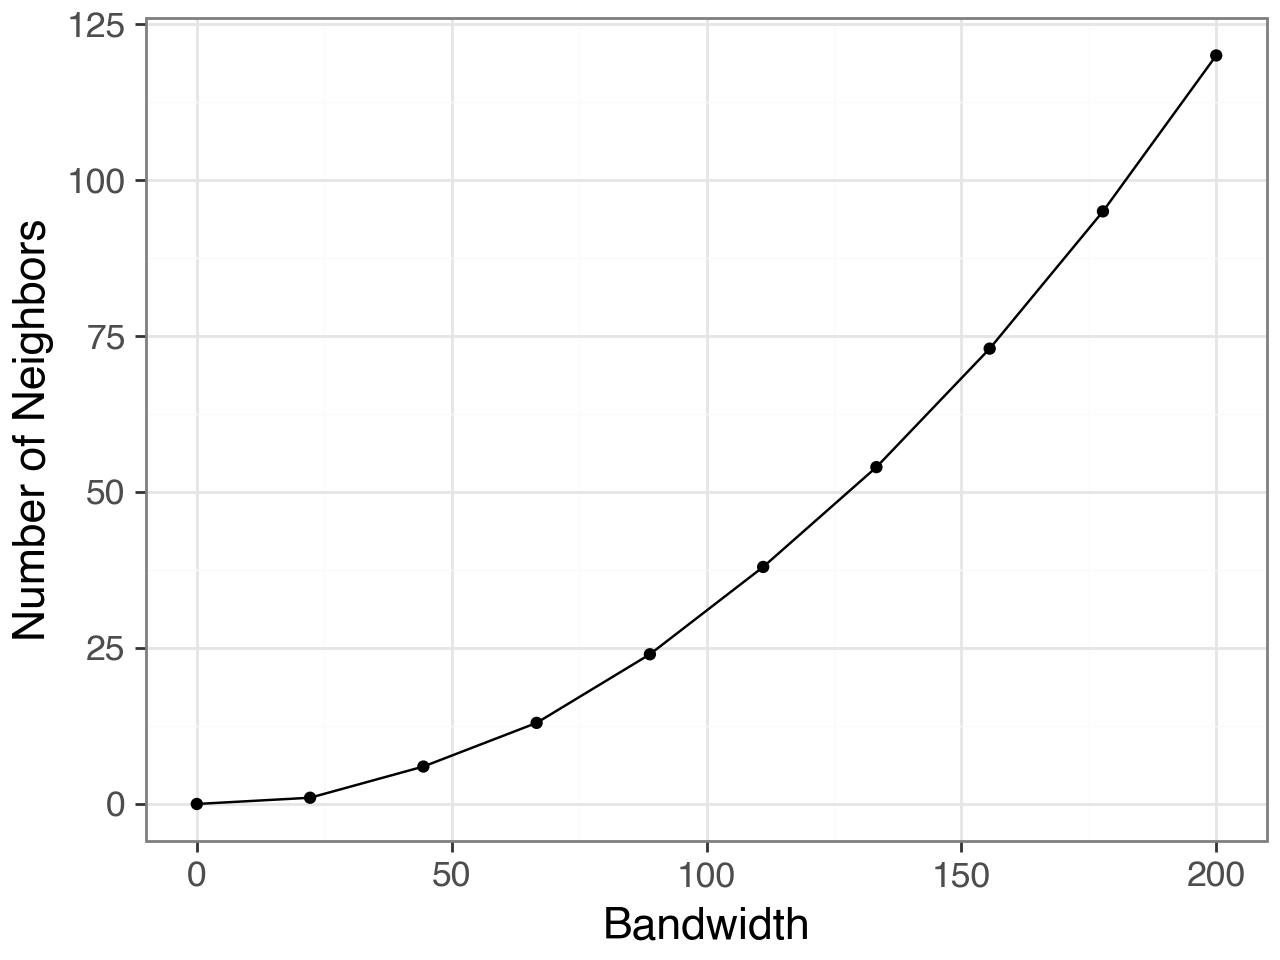

In [5]:
plot, _ = li.ut.query_bandwidth(
            coordinates=adata.obsm['spatial'],
            start=0,
            end=200,
            interval_n=10
)

plot

In [6]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

coords = adata.obsm['spatial']  # (n_cells × 2) array of centroids
k = 6

nbrs = NearestNeighbors(n_neighbors=k+1,  # +1 because the closest neighbor is itself at distance 0
                        algorithm='auto').fit(coords)
dists, _ = nbrs.kneighbors(coords)

# dists[:, 0] == 0 (self), so pick the k+1’th column for the k-th real neighbor:
sixth = dists[:, k]  

ℓ_median = float(np.median(sixth))
print("Median distance to 6th neighbor → ℓ ≈", ℓ_median)


Median distance to 6th neighbor → ℓ ≈ 43.3745073351402


# Spatial Neighbors

In [7]:
li.ut.spatial_neighbors(adata, bandwidth=43, cutoff = 0.1, kernel='gaussian', set_diag=True)

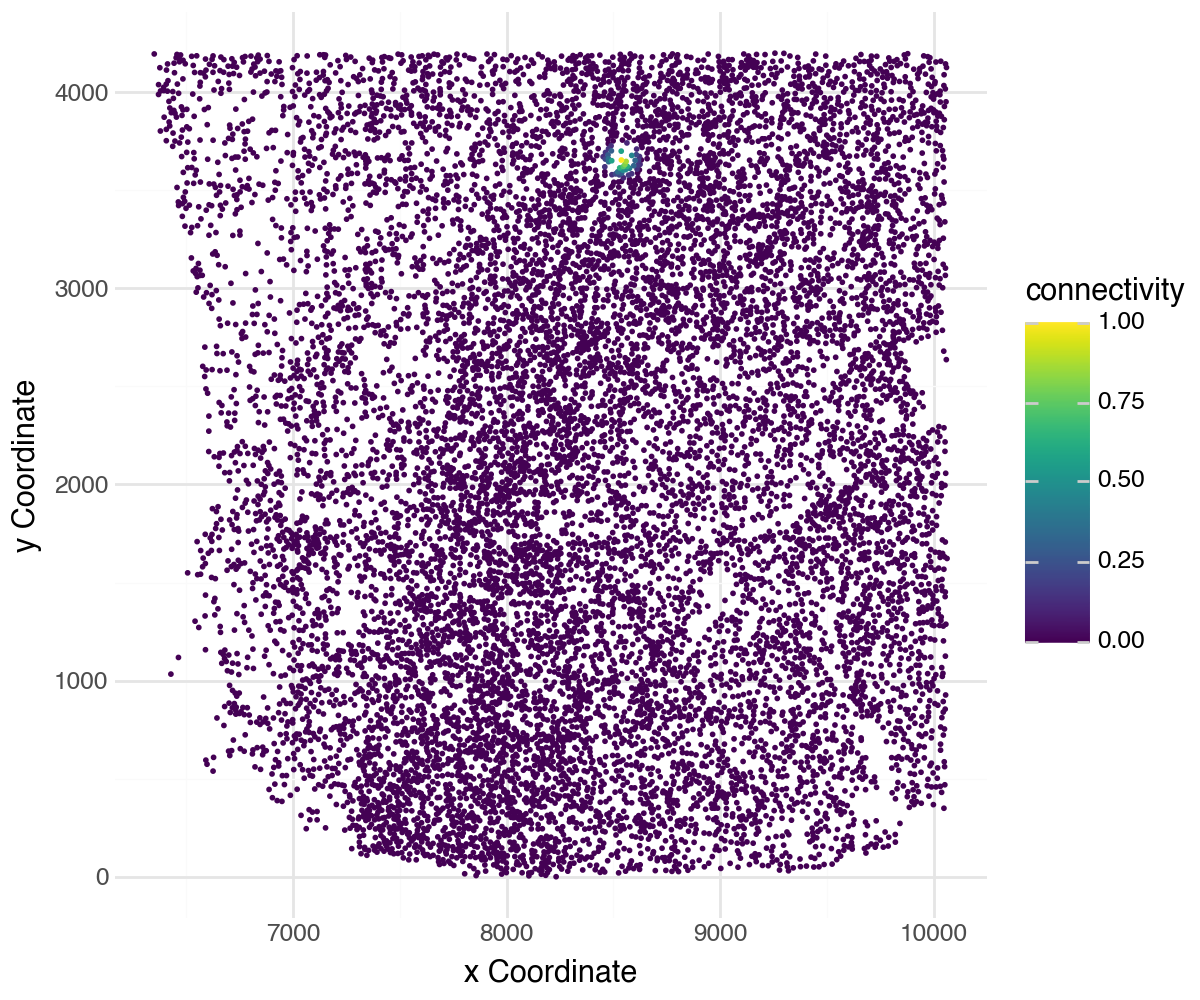

In [8]:
li.pl.connectivity(adata, idx=2000, size=0.2, figure_size=(6, 5))

# Identifying receptors

In [9]:
lrdata = li.mt.bivariate(adata,
                resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.05, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=True
                )

Using `.X`!
/Users/janzules/anaconda3/envs/spatial_analysis_env_2/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2308 features of mat are empty, they will be removed.
Using resource `mouseconsensus`.
100%|██████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.78it/s]


In [10]:
interaction_results = lrdata.var.sort_values("mean", ascending=False).head(10)
lrdata.var.sort_values("mean", ascending=False).head(10)

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
Apoe^Lrp1,Apoe,Lrp1,4.828095,0.521355,1.620548,0.191758,-0.017448,0.00,0.312115,0.181404
App^Cd74,App,Cd74,1.436991,0.167364,4.122237,0.451962,0.017370,0.00,0.287051,0.193297
Vim^Cd44,Vim,Cd44,5.115257,0.556643,0.905706,0.112971,0.116657,0.00,0.241731,0.222718
Spp1^Cd44,Spp1,Cd44,3.952241,0.431989,0.905706,0.112971,0.148247,0.00,0.239327,0.230388
Fn1^Nt5e,Fn1,Nt5e,2.782961,0.316965,0.866829,0.108471,0.121766,0.00,0.224360,0.251860
Fn1^Cd44,Fn1,Cd44,2.782961,0.316965,0.905706,0.112971,0.091001,0.00,0.214837,0.230187
Timp2^Itgb1,Timp2,Itgb1,1.917886,0.228231,1.052746,0.129470,0.075137,0.00,0.213184,0.238908
App^Lrp1,App,Lrp1,1.436991,0.167364,1.620548,0.191758,0.007369,0.11,0.206347,0.212231
Psap^Lrp1,Psap,Lrp1,1.519100,0.179048,1.620548,0.191758,0.000680,0.96,0.195340,0.204880


In [12]:
# interaction_results = lrdata.var.sort_values("morans", ascending=False).head(10)
lrdata.var.sort_values("morans", ascending=False).head(10)

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
Spp1^Cd44,Spp1,Cd44,3.952241,0.431989,0.905706,0.112971,0.148247,0.0,0.239327,0.230388
Fn1^Nt5e,Fn1,Nt5e,2.782961,0.316965,0.866829,0.108471,0.121766,0.0,0.224360,0.251860
Vim^Cd44,Vim,Cd44,5.115257,0.556643,0.905706,0.112971,0.116657,0.0,0.241731,0.222718
Fn1^Itga6,Fn1,Itga6,2.782961,0.316965,0.593900,0.076182,0.097238,0.0,0.175512,0.216355
Plau^Itga5,Plau,Itga5,1.266351,0.152759,0.665795,0.084314,0.091118,0.0,0.146235,0.216685
Fn1^Cd44,Fn1,Cd44,2.782961,0.316965,0.905706,0.112971,0.091001,0.0,0.214837,0.230187
Fn1^Sdc1,Fn1,Sdc1,2.782961,0.316965,0.644685,0.081393,0.090327,0.0,0.183711,0.220076
Col18a1^Ptprs,Col18a1,Ptprs,0.886235,0.110050,0.738941,0.093945,0.086729,0.0,0.145254,0.223647
Plau^Igf2r,Plau,Igf2r,1.266351,0.152759,0.466037,0.059288,0.085627,0.0,0.130985,0.216569


In [170]:
#Saving output to sample folder
top_interactions_out = results_out / "lrdata_results" 
lrdata_csv_out = top_interactions_out / f"{sample_name}_results.csv"
lrdata.var.sort_values("mean", ascending=False).head(10).to_csv(lrdata_csv_out)

# Save the images for each interaction
# Creating folder for sample figures
top_interactions_out_figs_out = top_interactions_out / f"{sample_name}"
os.makedirs(top_interactions_out_figs_out, exist_ok=True)
print(top_interactions_out_figs_out)

/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/onefer/results/lrdata_results/CyT72_1_4


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_37988/2635584921.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
... storing 'ligand' as categorical
... storing 'receptor' as categorical


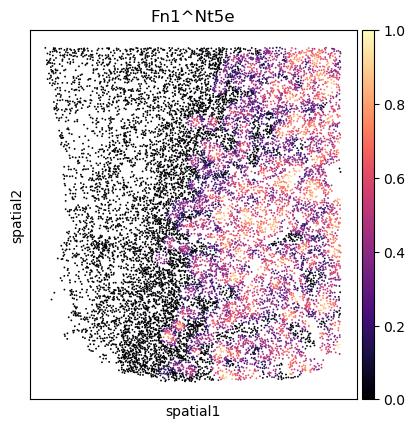

In [13]:
sc.pl.spatial(lrdata, 
              color="Fn1^Nt5e",
              size=0.23, 
              cmap="magma",
             library_id=adata.obs['TMA'].unique()[0],
             img_key=None)

In [172]:
for inter in interaction_results.index:
    inter_fig = top_interactions_out_figs_out / f"{inter}.png"
    print(inter_fig)
    axes = sc.pl.spatial(lrdata, 
                        color= inter,
                        size=0.23, 
                        cmap="magma",
                        library_id=adata.obs['TMA'].unique()[0],
                        img_key=None,
                        show=False)
    ax = axes[0]
    fig = ax.figure
    fig.savefig(inter_fig, dpi=300, bbox_inches='tight')
    plt.close(fig)
            
    

/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/onefer/results/lrdata_results/CyT72_1_4/Apoe^Lrp1.png


/tmp/ipykernel_1539/2263940038.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/onefer/results/lrdata_results/CyT72_1_4/App^Cd74.png


/tmp/ipykernel_1539/2263940038.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/onefer/results/lrdata_results/CyT72_1_4/C1qb^Lrp1.png


...

/tmp/ipykernel_1539/2263940038.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/onefer/results/lrdata_results/CyT72_1_4/Col1a2^Cd44.png


/tmp/ipykernel_1539/2263940038.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/onefer/results/lrdata_results/CyT72_1_4/Thbs1^Lrp1.png


/tmp/ipykernel_1539/2263940038.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


# Older Stuff

In [46]:
interaction_results.index[0:3]

Index(['Fn1^Itga6', 'Vim^Cd44', 'Spp1^Cd44'], dtype='object', name='interaction')

/tmp/ipykernel_1539/3358898635.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


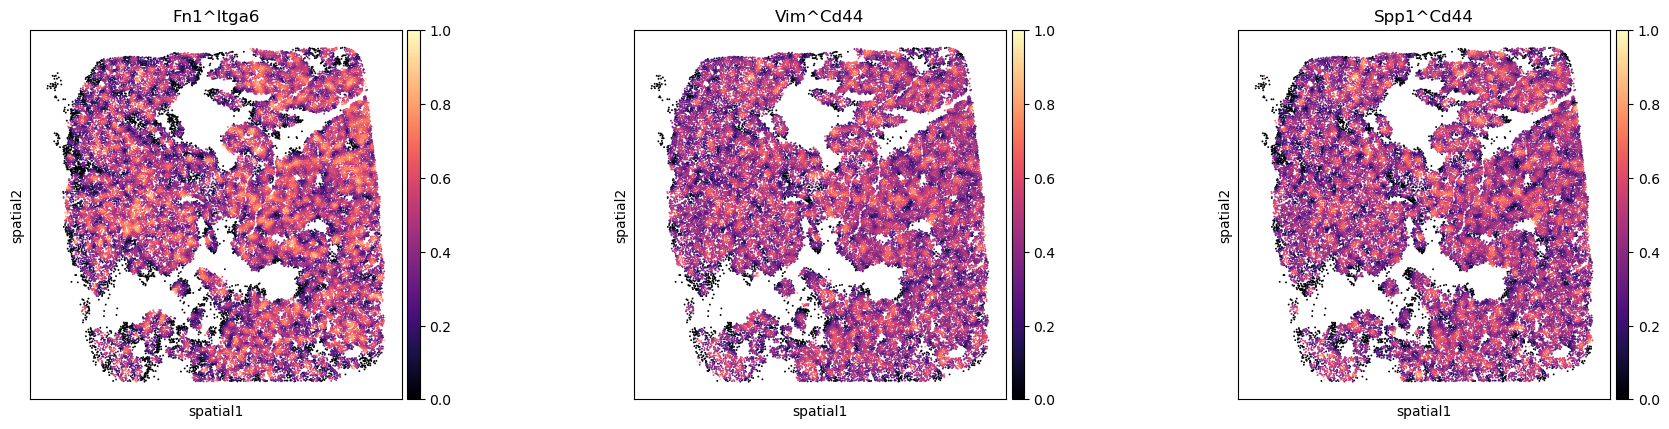

In [32]:
sc.pl.spatial(lrdata, 
              color=["Fn1^Itga6", "Vim^Cd44", "Spp1^Cd44"], #"Apoe^Lrp1",
              size=0.3, 
              cmap="magma",
             library_id="F07840",
             img_key=None)

/tmp/ipykernel_1539/2852872691.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


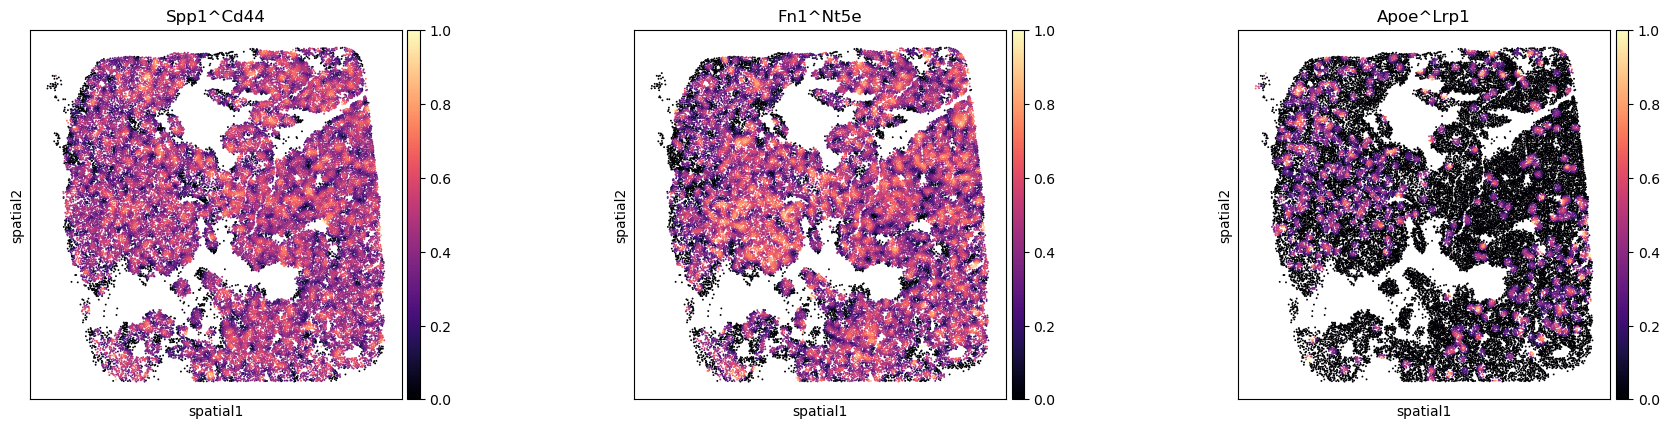

In [33]:
sc.pl.spatial(lrdata, 
              color=["Spp1^Cd44", "Fn1^Nt5e", "Apoe^Lrp1"], #"Apoe^Lrp1",
              size=0.3, 
              cmap="magma",
             library_id="F07840",
             img_key=None)

/tmp/ipykernel_1539/334598722.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


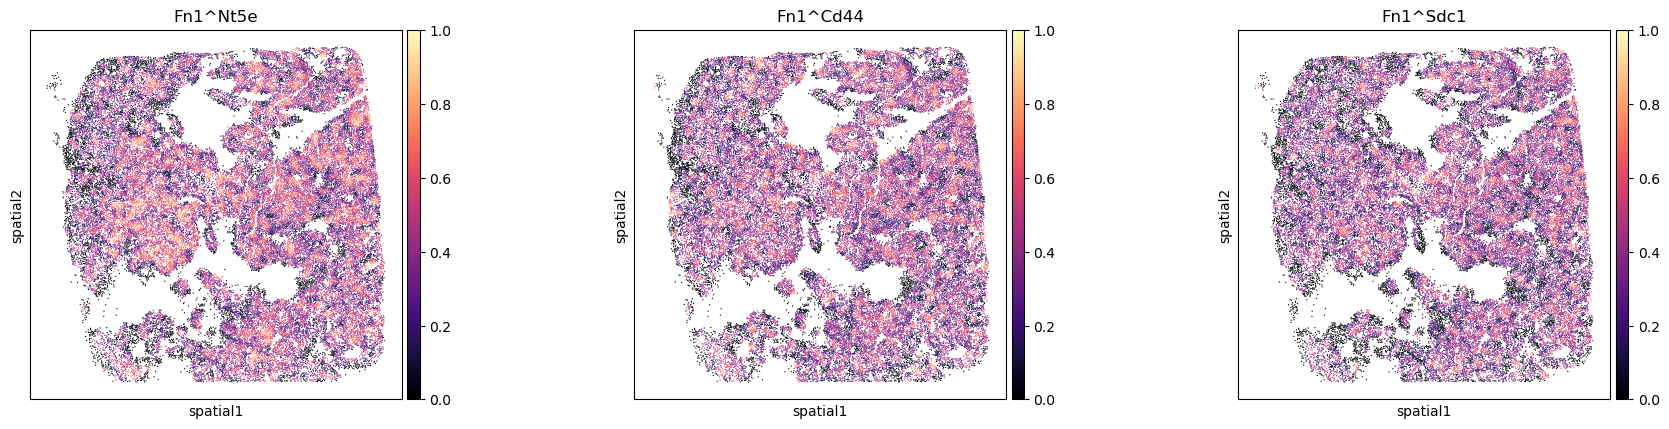

In [31]:
sc.pl.spatial(lrdata, 
              color=["Fn1^Nt5e", "Fn1^Cd44", "Fn1^Sdc1"], #"Apoe^Lrp1",
              size=0.2, 
              cmap="magma",
             library_id="F07840",
             img_key=None)

/tmp/ipykernel_1539/3017395314.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


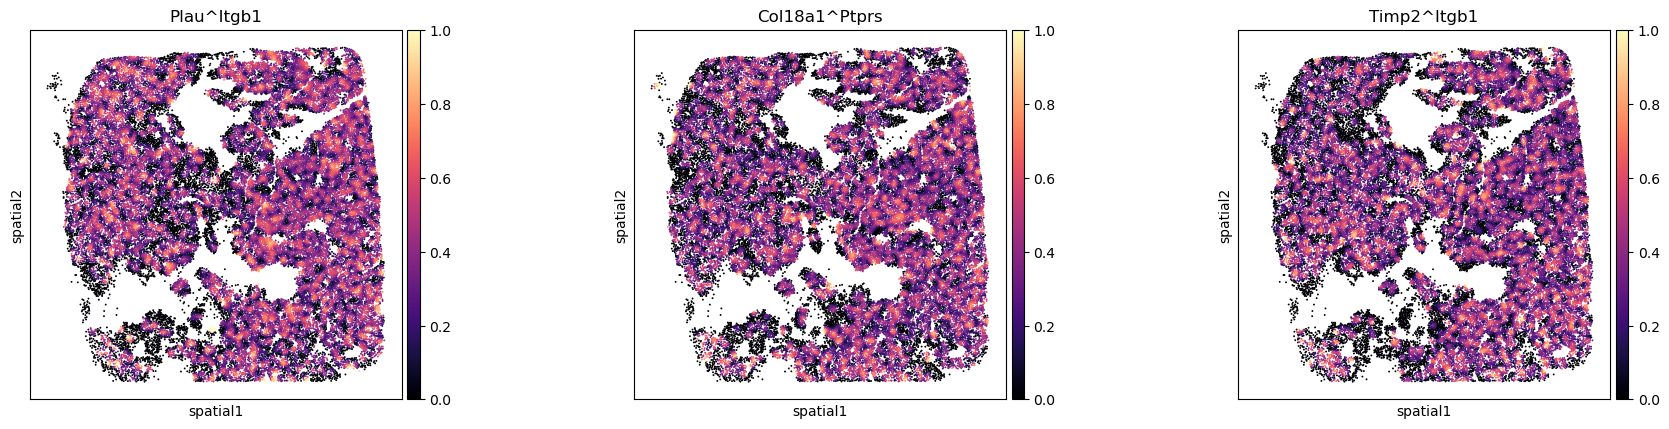

In [34]:
sc.pl.spatial(lrdata, 
              color=["Plau^Itgb1", "Col18a1^Ptprs", "Timp2^Itgb1"], #"Apoe^Lrp1",
              size=0.3, 
              cmap="magma",
             library_id="F07840",
             img_key=None)

In [41]:
# help(sc.pl.spatial)

In [76]:
sc.set_figure_params(dpi=80, dpi_save=300, format='png', frameon=False, transparent=True, figsize=[5,5])

/tmp/ipykernel_7217/2911547499.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


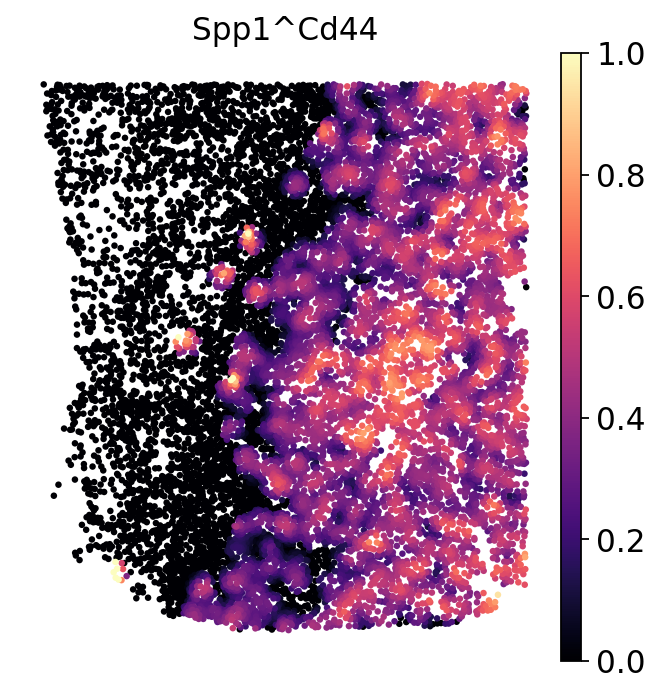

In [79]:
sc.pl.spatial(
    lrdata,
    color=["Spp1^Cd44"],
    size=0.5,
    cmap="magma",
    library_id="F07840",
    img_key=None
)

/tmp/ipykernel_7217/73516206.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


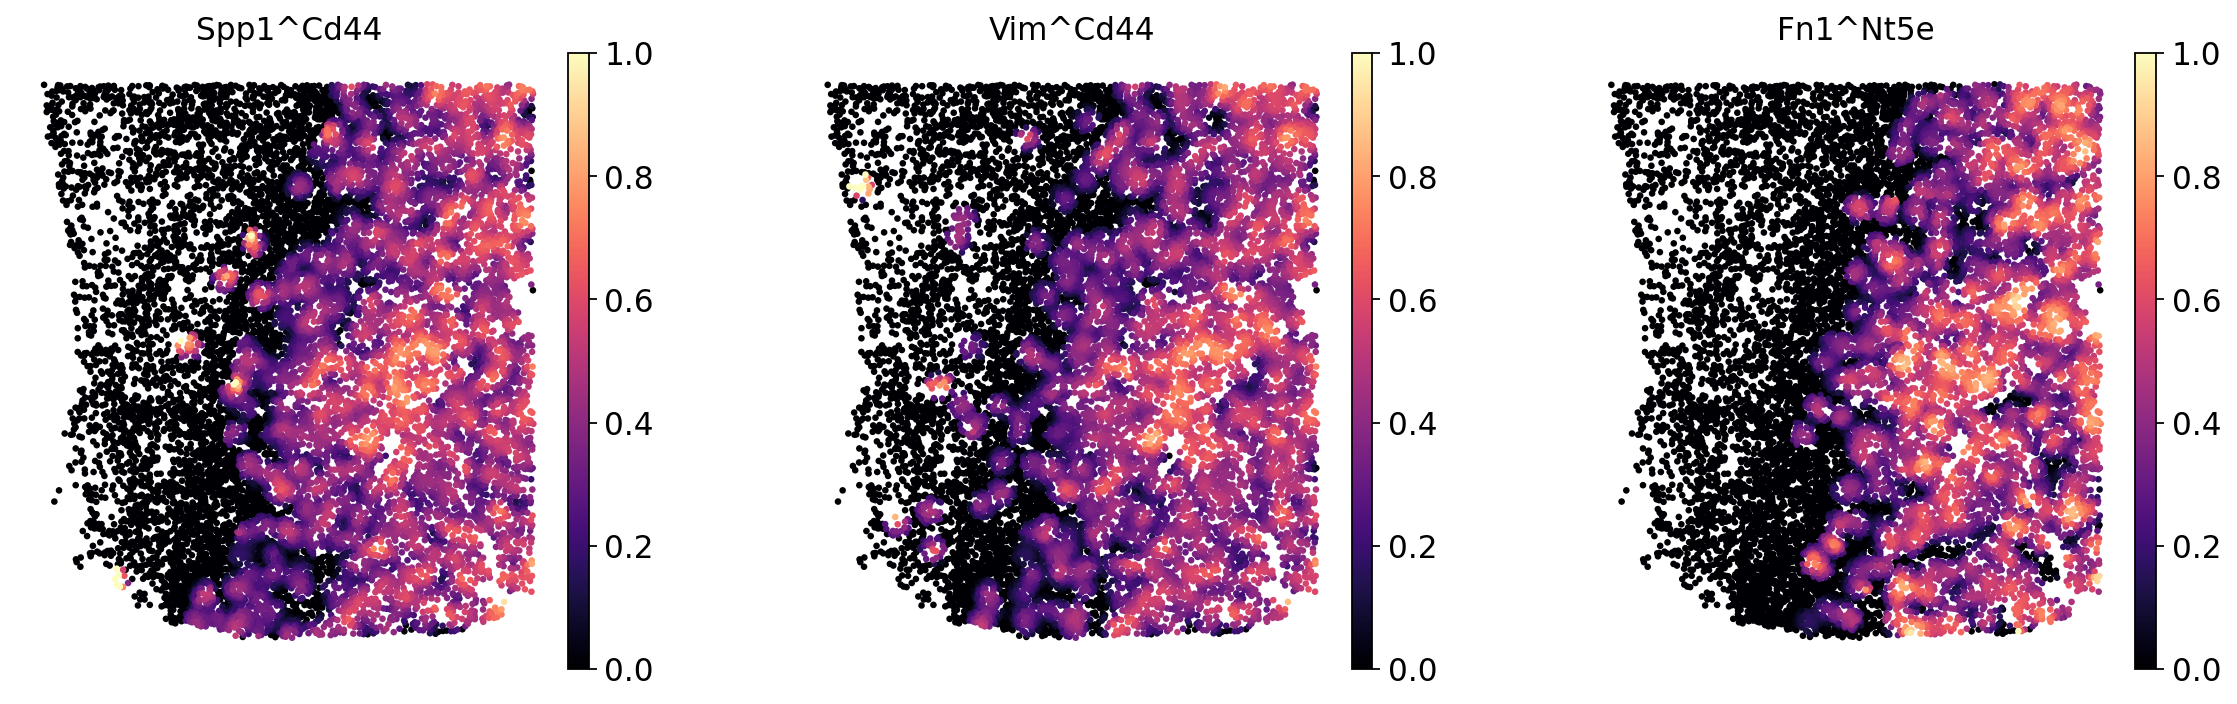

In [83]:
interactions_plot = 
sc.pl.spatial(lrdata, 
              color=["Spp1^Cd44", "Vim^Cd44", "Fn1^Nt5e"], #"Apoe^Lrp1",
              size=0.5, 
              cmap="magma",
             library_id="F07840",
             img_key=None)